<a href="https://colab.research.google.com/github/ShubhamP1028/Project-ADITI/blob/main/pd_snn_cnn_izhikevich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install norse torch torchvision plotly scikit-learn tqdm matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!apt-get install -y git-lfs -q
!git lfs install
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git --depth 1
!cd PlantVillage-Dataset && git lfs pull

Reading package lists...
Building dependency tree...
Reading state information...
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Git LFS initialized.
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163219, done.
remote: Counting objects: 100% (163219/163219), done.
remote: Compressing objects: 100% (163125/163125), done.
remote: Total 163219 (delta 93), reused 163214 (delta 93), pack-reused 0 (from 0)
Receiving objects: 100% (163219/163219), 2.00 GiB | 18.11 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Updating files: 100% (182404/182404), done.


In [ ]:
import os, gc, sys, time, copy, json, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")

#### Reproducibility

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{'─'*55}")
print(f"  Device : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU    : {props.name}")
    print(f"  VRAM   : {props.total_memory / 1e9:.1f} GB")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
  Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB
───────────────────────────────────────────────────────


#### SuperSpike Surrogate Gradient

In [ ]:
class SuperSpike(torch.autograd.Function):
    """
    Heaviside spike with SuperSpike surrogate gradient.

    Forward  : z = H(v − v_th)        [0 or 1, non-differentiable]
    Backward : ∂L/∂v ≈ ∂L/∂z × 1/(1 + |v − v_th|)²

    The surrogate allows gradients to flow through the discontinuous
    threshold during backpropagation, enabling end-to-end training.
    """
    @staticmethod
    def forward(ctx, v: torch.Tensor, v_th: float = 30.0) -> torch.Tensor:
        ctx.save_for_backward(v)
        ctx.v_th = v_th
        return (v >= v_th).float()

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        (v,) = ctx.saved_tensors
        surrogate = 1.0 / (1.0 + (v - ctx.v_th).abs()) ** 2
        return grad_output * surrogate, None


#### Izhikevich Parameter & State containers

In [ ]:
class IzhikevichParameters:
    """
    Standard Izhikevich (2003) dimensionless model parameters.

      dv/dt = 0.04v² + 5v + 140 − u + I_ext
      du/dt = a(bv − u)
      if v ≥ v_th : v ← c,  u ← u + d

    Args
    ────
    a   : recovery time constant  (small  = slow recovery)
    b   : sub-threshold sensitivity of u to v
    c   : after-spike reset membrane potential (mV)
    d   : after-spike recovery variable increment
    v_th: firing threshold (mV)
    dt  : integration timestep (ms, kept at 0.5 for stability)
    """
    def __init__(self, a=0.02, b=0.2, c=-65.0, d=8.0,
                 v_th=30.0, dt=0.5, name=""):
        self.a, self.b, self.c, self.d = a, b, c, d
        self.v_th = v_th
        self.dt   = dt
        self.name = name

    def __repr__(self):
        return (f"IzhikevichParameters("
                f"a={self.a}, b={self.b}, c={self.c}, d={self.d})")


In [ ]:
class IzhikevichState:
    """Holds membrane potential v and recovery variable u."""
    def __init__(self, v: torch.Tensor, u: torch.Tensor):
        self.v = v
        self.u = u

    def detach(self) -> "IzhikevichState":
        """Detach from computation graph (truncated BPTT)."""
        return IzhikevichState(v=self.v.detach(), u=self.u.detach())


#### Single-step Izhikevich dynamics

In [9]:
def izhikevich_step(
    input_current: torch.Tensor,
    state: IzhikevichState,
    params: IzhikevichParameters,
) -> tuple:
    """
    One Euler step of the Izhikevich neuron model.

    Parameters
    ──────────
    input_current : (batch, neurons) injected current from CNN features
    state         : current IzhikevichState
    params        : IzhikevichParameters

    Returns
    ───────
    (spikes, new_state)  where spikes ∈ {0,1} with surrogate gradient
    """
    v, u = state.v, state.u
    dt   = params.dt

    # ── Sub-threshold membrane dynamics (Euler integration) ──────────────
    dv = (0.04 * v * v + 5.0 * v + 140.0 - u + input_current) * dt
    du = params.a * (params.b * v - u) * dt

    v_new = v + dv
    u_new = u + du

    # Numerical stability clamps
    v_new = torch.clamp(v_new, -100.0, 60.0)
    u_new = torch.clamp(u_new, -100.0, 100.0)

    # ── Spike detection (Heaviside + surrogate gradient) ─────────────────
    spikes = SuperSpike.apply(v_new, params.v_th)

    # ── Post-spike reset (soft, keeps gradient path through spikes) ───────
    # v resets to c only at spike sites, differentiable via (1-spikes)
    v_out = v_new * (1.0 - spikes) + params.c * spikes
    # u jumps by d at spike sites
    u_out = u_new + params.d * spikes

    return spikes, IzhikevichState(v=v_out, u=u_out)

####  Norse implementation if available

In [ ]:
_using_norse = False
try:
    from norse.torch.functional.izhikevich import (
        IzhikevichParameters as _NP,
        IzhikevichState      as _NS,
        izhikevich_feed_forward_step,
    )

    def _norse_step(input_current, state, params):
        np_ = _NP(a=params.a, b=params.b, c=params.c, d=params.d)
        ns  = _NS(v=state.v, u=state.u)
        spikes, ns2 = izhikevich_feed_forward_step(input_current, ns, np_)
        return spikes, IzhikevichState(v=ns2.v, u=ns2.u)

    # izhikevich_step = _norse_step   # ← uncomment to use Norse kernels
    _using_norse = True
    print("✅ Norse-torch found — custom SuperSpike surrogate in use "
          "(swap to Norse via uncommenting line above)")
except ImportError:
    print("ℹ️  Norse not installed — using built-in Izhikevich + SuperSpike")


✅ Norse-torch found — custom SuperSpike surrogate in use (swap to Norse via uncommenting line above)


In [ ]:
NEURON_CONFIGS: dict = {
    "Regular_Spiking": dict(
        params  = IzhikevichParameters(a=0.02, b=0.20, c=-65.0, d=8.0, name="RS"),
        color   = "#3B82F6",
        display = "Regular Spiking (RS)",
        bio     = "Tonic firing · excitatory pyramidal neurons",
    ),
    "Fast_Spiking": dict(
        params  = IzhikevichParameters(a=0.10, b=0.20, c=-65.0, d=2.0, name="FS"),
        color   = "#EF4444",
        display = "Fast Spiking (FS)",
        bio     = "High-frequency · inhibitory interneurons",
    ),
    "Chattering": dict(
        params  = IzhikevichParameters(a=0.02, b=0.20, c=-50.0, d=2.0, name="CH"),
        color   = "#10B981",
        display = "Chattering (CH)",
        bio     = "Burst trains · visual cortex layers 2/3",
    ),
    "Intrinsic_Bursting": dict(
        params  = IzhikevichParameters(a=0.02, b=0.20, c=-55.0, d=4.0, name="IB"),
        color   = "#F59E0B",
        display = "Intrinsic Bursting (IB)",
        bio     = "Initial burst then tonic · layer 5 pyramidal",
    ),
    "Low_Threshold_Spiking": dict(
        params  = IzhikevichParameters(a=0.02, b=0.25, c=-65.0, d=2.0, name="LTS"),
        color   = "#8B5CF6",
        display = "Low Threshold Spiking (LTS)",
        bio     = "Low-threshold spiking · inhibitory interneurons",
    ),
}

In [ ]:
print("\nNeuron Type Configurations")
print(f"{'─'*65}")
print(f"  {'Type':<30}  a      b      c      d")
print(f"{'─'*65}")
for k, v in NEURON_CONFIGS.items():
    p = v["params"]
    print(f"  {v['display']:<30}  {p.a:.2f}  {p.b:.2f}  {p.c:.0f}   {p.d:.0f}")


Neuron Type Configurations
─────────────────────────────────────────────────────────────────
  Type                            a      b      c      d
─────────────────────────────────────────────────────────────────
  Regular Spiking (RS)            0.02  0.20  -65   8
  Fast Spiking (FS)               0.10  0.20  -65   2
  Chattering (CH)                 0.02  0.20  -50   2
  Intrinsic Bursting (IB)         0.02  0.20  -55   4
  Low Threshold Spiking (LTS)     0.02  0.25  -65   2


In [ ]:
def visualize_spike_patterns(configs: dict, T: int = 350, I_ext: float = 10.0):
    """
    Single-neuron voltage traces for each Izhikevich type.
    Gives an intuitive preview of the temporal dynamics that the
    SNN layers will exploit during disease classification.
    """
    n = len(configs)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.2 * n))
    fig.patch.set_facecolor("#0d1117")
    fig.suptitle(
        "Izhikevich Neuron Spike Patterns  (I_ext = 10 pA)",
        color="white", fontsize=13, fontweight="bold", y=1.01,
    )

    for idx, (name, cfg) in enumerate(configs.items()):
        ax  = axes[idx]
        p   = cfg["params"]
        col = cfg["color"]

        # Simulate
        v_trace, spike_times = [], []
        v = torch.tensor([-65.0])
        u = torch.tensor([p.b * -65.0])
        st = IzhikevichState(v=v, u=u)

        for t in range(T):
            spk, st = izhikevich_step(torch.tensor([I_ext]), st, p)
            v_trace.append(st.v.item())
            if spk.item() > 0.5:
                spike_times.append(t)

        ax.set_facecolor("#161b22")
        ax.plot(v_trace, color=col, linewidth=1.6, zorder=3)
        ax.fill_between(range(T), v_trace, -90,
                        color=col, alpha=0.08, zorder=2)

        # Mark spikes
        for st_t in spike_times:
            ax.axvline(st_t, color=col, alpha=0.35, linewidth=0.8, zorder=1)

        ax.axhline(p.v_th, color="#aaaaaa", linewidth=0.8,
                   linestyle="--", alpha=0.5, label=f"threshold {p.v_th} mV")
        ax.set_ylabel("V (mV)", color="#aaa", fontsize=9)
        ax.set_xlim(0, T)
        ax.set_ylim(-90, 50)

        badge = f"  {cfg['display']}   ({len(spike_times)} spikes)   {cfg['bio']}"
        ax.set_title(badge, color="white", fontsize=9.5, loc="left", pad=4)
        ax.tick_params(colors="#888", labelsize=8)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["bottom", "left"]:
            ax.spines[spine].set_color("#333")
        ax.grid(axis="y", color="#222", linewidth=0.7)

        if idx < n - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time step", color="#aaa", fontsize=10)

    plt.tight_layout()
    plt.savefig("spike_patterns.png", dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    print("✅  spike_patterns.png saved")


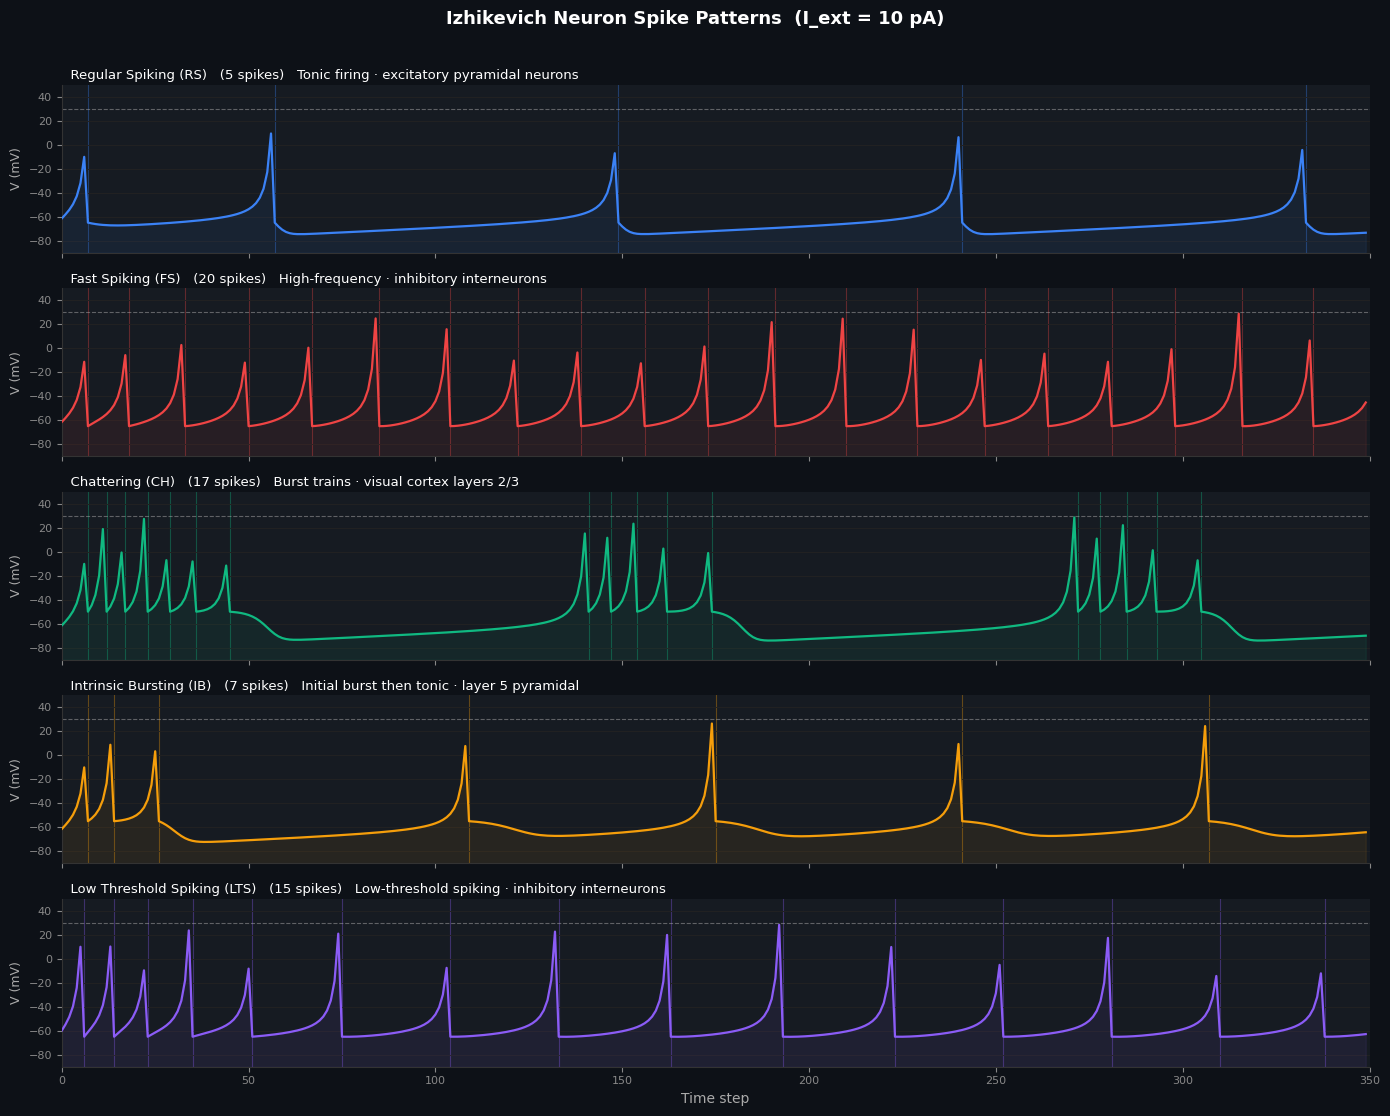

✅  spike_patterns.png saved


In [ ]:
visualize_spike_patterns(NEURON_CONFIGS)

#### Hyperparameters

In [15]:
IMG_SIZE        = 128          # resize all images to 128×128
BATCH_SIZE      = 32
NUM_WORKERS     = 2
SUBSET_FRACTION = 0.35         # 0.35 → ~19k images; 1.0 → full 54k
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
# TEST_RATIO    = 1 - TRAIN - VAL = 0.15


#### Candidate Dataset roots

In [16]:
_CANDIDATE_PATHS = [
    "./PlantVillage-Dataset/raw/color",
    "./PlantVillage/color",
    "/content/PlantVillage-Dataset/raw/color",
    "/content/PlantVillage/color",
    "/content/plantvillage_dataset/color",
    "./plantvillage_dataset/color",
]

def _find_dataset() -> str | None:
    for p in _CANDIDATE_PATHS:
        if os.path.isdir(p):
            subdirs = [d for d in os.listdir(p)
                       if os.path.isdir(os.path.join(p, d))]
            if len(subdirs) >= 3:
                print(f"✅  Dataset found : {p}")
                print(f"    Classes       : {len(subdirs)}")
                print(f"    Sample        : {subdirs[:4]} …")
                return p
    return None


def _make_dummy_dataset(root="./dummy_plantvillage", n_cls=5, n_per=150) -> str:
    """Creates a tiny RGB dummy dataset for smoke-testing the pipeline."""
    from PIL import Image as PILImage

    print("⚠️   Real dataset not found — building synthetic dummy …")
    cls_names = [f"Plant_{c}" for c in range(n_cls)]
    for c in cls_names:
        d = os.path.join(root, c)
        os.makedirs(d, exist_ok=True)
        for i in range(n_per):
            arr = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
            PILImage.fromarray(arr).save(os.path.join(d, f"img_{i:04d}.jpg"))

    print(f"    Dummy dataset : {n_cls} classes × {n_per} images = {n_cls*n_per}")
    return root
dataset_root = _find_dataset() or _make_dummy_dataset()

✅  Dataset found : ./PlantVillage-Dataset/raw/color
    Classes       : 38
    Sample        : ['Pepper,_bell___Bacterial_spot', 'Squash___Powdery_mildew', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Corn_(maize)___Northern_Leaf_Blight'] …


#### Transform

In [17]:
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
])

#### Build Splits

In [18]:
_base = datasets.ImageFolder(dataset_root)          # no transform, just for indexing
NUM_CLASSES = len(_base.classes)
CLASS_NAMES = _base.classes

N_TOTAL = len(_base)
if SUBSET_FRACTION < 1.0:
    n_sub   = int(N_TOTAL * SUBSET_FRACTION)
    sub_idx = torch.randperm(N_TOTAL, generator=torch.Generator().manual_seed(SEED))[:n_sub].tolist()
else:
    sub_idx = list(range(N_TOTAL))

n_sub   = len(sub_idx)
n_train = int(n_sub * TRAIN_RATIO)
n_val   = int(n_sub * VAL_RATIO)
n_test  = n_sub - n_train - n_val

rng = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_sub, generator=rng).tolist()
train_idx = [sub_idx[i] for i in perm[:n_train]]
val_idx   = [sub_idx[i] for i in perm[n_train:n_train+n_val]]
test_idx  = [sub_idx[i] for i in perm[n_train+n_val:]]

Reload with appropriate transform

In [19]:
_train_ds = datasets.ImageFolder(dataset_root, transform=train_transform)
_eval_ds  = datasets.ImageFolder(dataset_root, transform=eval_transform)

train_data = Subset(_train_ds, train_idx)
val_data   = Subset(_eval_ds,  val_idx)
test_data  = Subset(_eval_ds,  test_idx)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataset Summary")
print(f"{'─'*45}")
print(f"  Classes   : {NUM_CLASSES}")
print(f"  Total     : {N_TOTAL:,}")
print(f"  Subset    : {n_sub:,}  ({SUBSET_FRACTION*100:.0f}%)")
print(f"  Train     : {n_train:,}")
print(f"  Val       : {n_val:,}")
print(f"  Test      : {n_test:,}")
print(f"  Batch     : {BATCH_SIZE}")
print(f"  Batches/epoch : {len(train_loader)}")


Dataset Summary
─────────────────────────────────────────────
  Classes   : 38
  Total     : 54,305
  Subset    : 19,006  (35%)
  Train     : 13,304
  Val       : 2,850
  Test      : 2,852
  Batch     : 32
  Batches/epoch : 415


Izhikevich SNN Layer


In [20]:
class IzhikevichSNNLayer(nn.Module):
    """
    A fully-connected SNN layer whose neurons obey Izhikevich dynamics.

    Processing pipeline per forward call
    ─────────────────────────────────────
    1. Project input to neuron space  :  Linear(in → out)
    2. Normalise + scale to pA range  :  LayerNorm → tanh → ×I_scale
    3. Simulate T Euler steps         :  izhikevich_step × T
    4. Return mean firing rate        :  Σ spikes / T  ∈ [0, 1]

    Gradients flow through:
      • Linear weights (always differentiable)
      • Spike function via SuperSpike surrogate gradient
    States are detached each step (truncated BPTT) for training stability.
    """

    def __init__(self, in_features: int, out_features: int,
                 params: IzhikevichParameters, T: int = 8):
        super().__init__()
        self.out_features = out_features
        self.params       = params
        self.T            = T

        self.linear       = nn.Linear(in_features, out_features, bias=True)
        self.layer_norm   = nn.LayerNorm(out_features)
        # Learnable current magnitude (initialised near the Izhikevich
        # input range of ~10-20 pA so neurons fire reliably)
        self.current_mag  = nn.Parameter(torch.tensor(12.0))

        nn.init.kaiming_normal_(self.linear.weight, mode="fan_in",
                                nonlinearity="relu")
        nn.init.zeros_(self.linear.bias)

    # ------------------------------------------------------------------
    def _init_state(self, batch: int, dev, dtype) -> IzhikevichState:
        v = torch.full((batch, self.out_features), -65.0,
                       device=dev, dtype=dtype)
        u = torch.full((batch, self.out_features),
                       self.params.b * -65.0,
                       device=dev, dtype=dtype)
        return IzhikevichState(v=v, u=u)

    # ------------------------------------------------------------------
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)

        # Project → normalise → scale to current injection (pA)
        raw   = self.layer_norm(self.linear(x))         # (B, out)
        I_inj = torch.tanh(raw) * self.current_mag.abs()  # bounded pA

        state = self._init_state(B, x.device, x.dtype)
        acc   = torch.zeros(B, self.out_features,
                            device=x.device, dtype=x.dtype)

        for _ in range(self.T):
            # Optional: small noise for richer temporal dynamics
            I_t   = I_inj + 0.3 * torch.randn_like(I_inj)
            spk, state = izhikevich_step(I_t, state, self.params)
            acc  += spk
            state = state.detach()   # truncated BPTT

        return acc / self.T          # mean spike rate ∈ [0, 1]

CNN Backbone

In [21]:
class CNNBackbone(nn.Module):
    """
    Four-stage convolutional feature extractor.

    Input  : (B, 3, 128, 128)
    Output : (B, feature_dim)

    Stage sizes (channels × spatial)
    ─────────────────────────────────
      Stage 1 :  32 × 64×64
      Stage 2 :  64 × 32×32
      Stage 3 : 128 × 16×16
      Stage 4 : 256 ×  4× 4  (AdaptiveAvgPool)
      Flatten + Linear → feature_dim
    """

    def __init__(self, feature_dim: int = 512):
        super().__init__()
        self.feature_dim = feature_dim

        def _block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin,  cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.GELU(),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.GELU(),
            )

        self.stage1 = nn.Sequential(_block(3,   32),  nn.MaxPool2d(2))
        self.stage2 = nn.Sequential(_block(32,  64),  nn.MaxPool2d(2))
        self.stage3 = nn.Sequential(_block(64,  128), nn.MaxPool2d(2))
        self.stage4 = nn.Sequential(_block(128, 256), nn.AdaptiveAvgPool2d(4))

        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, feature_dim, bias=False),
            nn.LayerNorm(feature_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        return self.projector(x)

Full SNN Model

In [22]:
class PlantDiseaseSNN(nn.Module):
    """
    Plant Disease Classification via Izhikevich SNN

    Architecture
    ────────────
    Image  (3 × 128 × 128)
      ↓  CNNBackbone           → 512-d feature vector
      ↓  IzhikevichSNNLayer 1  → 256 neurons  (T timesteps)
      ↓  IzhikevichSNNLayer 2  → 128 neurons  (T timesteps)
      ↓  Skip connection       feature → 128 (sigmoid gating)
      ↓  Classifier FC         128 → num_classes

    The skip connection preserves discriminative CNN features
    even when SNN firing rates are near-zero early in training.
    """

    def __init__(
        self,
        neuron_params: IzhikevichParameters,
        num_classes:   int,
        feature_dim:   int  = 512,
        snn_hidden:    int  = 256,
        T:             int  = 8,
        name:          str  = "",
    ):
        super().__init__()
        self.name          = name
        self.neuron_params = neuron_params

        self.cnn  = CNNBackbone(feature_dim=feature_dim)
        self.snn1 = IzhikevichSNNLayer(feature_dim,   snn_hidden,      neuron_params, T)
        self.snn2 = IzhikevichSNNLayer(snn_hidden,    snn_hidden // 2, neuron_params, T)

        # Skip: gates CNN features directly into classifier input
        self.skip = nn.Sequential(
            nn.Linear(feature_dim, snn_hidden // 2, bias=False),
            nn.Sigmoid(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(snn_hidden // 2, 128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

        self._param_count = sum(p.numel() for p in self.parameters())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats   = self.cnn(x)                          # (B, 512)
        snn_out = self.snn2(self.snn1(feats))          # (B, 128)  spike rates
        gated   = snn_out + self.skip(feats)           # residual gating
        return self.classifier(gated)                  # (B, C)


Sanity check

In [23]:
_demo = PlantDiseaseSNN(
    NEURON_CONFIGS["Regular_Spiking"]["params"],
    NUM_CLASSES, name="demo"
).to(device)

with torch.no_grad():
    _out = _demo(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device))

print(f"\nModel Architecture")
print(f"{'─'*45}")
print(f"  Input         : (B, 3, {IMG_SIZE}, {IMG_SIZE})")
print(f"  CNN output    : (B, 512)")
print(f"  SNN Layer 1   : 512 → 256  (Izhikevich × T)")
print(f"  SNN Layer 2   : 256 → 128  (Izhikevich × T)")
print(f"  Classifier    : 128 → {NUM_CLASSES}")
print(f"  Output        : {_out.shape}")
print(f"  Parameters    : {_demo._param_count:,}")
del _demo
gc.collect()


Model Architecture
─────────────────────────────────────────────
  Input         : (B, 3, 128, 128)
  CNN output    : (B, 512)
  SNN Layer 1   : 512 → 256  (Izhikevich × T)
  SNN Layer 2   : 256 → 128  (Izhikevich × T)
  Classifier    : 128 → 38
  Output        : torch.Size([2, 38])
  Parameters    : 3,523,336


20228

In [ ]:
def _grad_norm(model: nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return total ** 0.5


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    """Run a single training epoch, return (avg_loss, avg_acc, avg_grad_norm)."""
    model.train()
    loss_sum = acc_sum = n = 0
    gnorms = []

    bar = tqdm(loader, desc="  train", leave=False, ncols=90)
    for imgs, lbls in bar:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            from torch.cuda.amp import autocast
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            gnorms.append(_grad_norm(model))
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            gnorms.append(_grad_norm(model))
            optimizer.step()

        bs     = imgs.size(0)
        correct = (logits.detach().argmax(1) == lbls).sum().item()
        loss_sum += loss.item() * bs
        acc_sum  += correct
        n        += bs

        bar.set_postfix(loss=f"{loss.item():.3f}",
                        acc=f"{correct/bs:.3f}")

    return loss_sum / n, acc_sum / n, float(np.mean(gnorms))


In [ ]:
@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    """Return (avg_loss, avg_acc) on a dataloader."""
    model.eval()
    loss_sum = acc_sum = n = 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = model(imgs)
        loss   = criterion(logits, lbls)
        bs     = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum  += (logits.argmax(1) == lbls).sum().item()
        n        += bs

    return loss_sum / n, acc_sum / n


Train model

In [ ]:
def train_model(model: PlantDiseaseSNN, cfg: dict) -> dict:
    """
    Full training loop for one SNN model.

    Returns a history dict with:
      train_loss, val_loss, train_acc, val_acc,
      grad_norms, lr, best_val_acc
    """
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer  = optim.AdamW(model.parameters(),
                             lr=cfg["lr"],
                             weight_decay=cfg["weight_decay"])
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(
                     optimizer, T_max=cfg["epochs"], eta_min=1e-6)
    scaler     = (torch.cuda.amp.GradScaler()
                  if device.type == "cuda" else None)

    history    = dict(train_loss=[], val_loss=[], train_acc=[],
                      val_acc=[], grad_norms=[], lr=[])
    best_acc   = 0.0
    best_state = None
    patience   = 0

    bar_name   = f"{model.name} [{NEURON_CONFIGS[model.name]['params'].name}]"
    print(f"\n{'═'*62}")
    print(f"  ▶  {bar_name}")
    print(f"{'═'*62}")

    for ep in range(cfg["epochs"]):
        t0 = time.time()

        tr_loss, tr_acc, gnorm = train_one_epoch(model, train_loader,
                                                  optimizer, criterion, scaler)
        vl_loss, vl_acc        = evaluate_loader(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["grad_norms"].append(gnorm)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = copy.deepcopy(model.state_dict())
            patience   = 0
            mark       = " ✦"
        else:
            patience += 1
            mark      = ""

        elapsed = time.time() - t0
        print(f"  ep {ep+1:2d}/{cfg['epochs']}  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}  "
              f"‖∇‖={gnorm:.3f}  {elapsed:.1f}s{mark}")

        if patience >= cfg.get("patience", 8):
            print(f"  ⏸  early stop (patience={cfg['patience']})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_val_acc"] = best_acc
    print(f"  ✅  Best val accuracy: {best_acc*100:.2f}%")
    return history

Train all 5 models

In [28]:
TRAIN_CFG = dict(
    epochs       = 25,    # increase to 40-50 for production runs
    lr           = 3e-4,
    weight_decay = 1e-4,
    patience     = 8,
)

print(f"\n🚀  Training 5 Izhikevich SNN models")
print(f"    {TRAIN_CFG}")
print(f"    Train batches/epoch : {len(train_loader)}")
print()

all_histories: dict = {}
all_models:    dict = {}

for neuron_name, ncfg in NEURON_CONFIGS.items():
    model = PlantDiseaseSNN(
        neuron_params = ncfg["params"],
        num_classes   = NUM_CLASSES,
        feature_dim   = 512,
        snn_hidden    = 256,
        T             = 8,
        name          = neuron_name,
    ).to(device)

    hist = train_model(model, TRAIN_CFG)

    all_histories[neuron_name] = hist
    all_models[neuron_name]    = model

    torch.cuda.empty_cache() if device.type == "cuda" else None
    gc.collect()


🚀  Training 5 Izhikevich SNN models
    {'epochs': 25, 'lr': 0.0003, 'weight_decay': 0.0001, 'patience': 8}
    Train batches/epoch : 415


══════════════════════════════════════════════════════════════
  ▶  Regular_Spiking [RS]
══════════════════════════════════════════════════════════════


  train:   0%|                                                    | 0/415 [00:00<?, ?it/s]

  ep  1/25  tr_loss=2.9740  tr_acc=0.2684  vl_loss=2.3754  vl_acc=0.4316  ‖∇‖=0.990  88.7s ✦


  train:   0%|                                                    | 0/415 [00:00<?, ?it/s]

  ep  2/25  tr_loss=2.3295  tr_acc=0.4561  vl_loss=1.9541  vl_acc=0.5926  ‖∇‖=nan  62.2s ✦


...

  ep 23/25  tr_loss=0.9204  tr_acc=0.9496  vl_loss=0.8150  vl_acc=0.9751  ‖∇‖=0.999  63.3s ✦


  train:   0%|                                                    | 0/415 [00:00<?, ?it/s]

  ep 24/25  tr_loss=0.9217  tr_acc=0.9480  vl_loss=0.8141  vl_acc=0.9740  ‖∇‖=0.999  61.5s


  train:   0%|                                                    | 0/415 [00:00<?, ?it/s]

  ep 25/25  tr_loss=0.9180  tr_acc=0.9510  vl_loss=0.8148  vl_acc=0.9751  ‖∇‖=0.997  63.3s
  ✅  Best val accuracy: 97.51%


Leaderboard

In [29]:
print(f"\n{'═'*55}")
print("  TRAINING COMPLETE — VAL LEADERBOARD")
print(f"{'═'*55}")
ranked = sorted(all_histories.items(),
                key=lambda x: -x[1]["best_val_acc"])
for rank, (name, hist) in enumerate(ranked, 1):
    medal = ["🥇", "🥈", "🥉", "  4.", "  5."][rank - 1]
    print(f"  {medal}  {NEURON_CONFIGS[name]['display']:<32} "
          f"{hist['best_val_acc']*100:6.2f}%")
print(f"{'═'*55}")


═══════════════════════════════════════════════════════
  TRAINING COMPLETE — VAL LEADERBOARD
═══════════════════════════════════════════════════════
  🥇  Chattering (CH)                   97.68%
  🥈  Regular Spiking (RS)              97.61%
  🥉  Low Threshold Spiking (LTS)       97.51%
    4.  Intrinsic Bursting (IB)           97.40%
    5.  Fast Spiking (FS)                 97.23%
═══════════════════════════════════════════════════════


Helper : smooth a list

In [30]:
def _smooth(arr, w=3):
    arr = np.array(arr)
    pad = np.pad(arr, w // 2, mode="edge")
    return np.convolve(pad, np.ones(w) / w, mode="valid")[: len(arr)]

Plotly Dashboard

In [33]:
def build_plotly_dashboard(histories, configs):
    names    = list(histories.keys())
    colors   = {n: configs[n]["color"]   for n in names}
    labels   = {n: configs[n]["display"] for n in names}

    # Helper to convert hex to rgba string
    def hex_to_rgba(hex_color, alpha):
        hex_color = hex_color.lstrip('#')
        lv = len(hex_color)
        rgb = tuple(int(hex_color[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
        return f'rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha})'

    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            "Training Loss",
            "Validation Accuracy (%)",
            "Gradient L2 Norm",
            "Loss–Accuracy Trajectory",
            "Best Val Accuracy (Bar)",
            "Epochs to 70 % of Best Acc",
            "Train–Val Loss Gap",
            "Smoothed Acc Gain per Epoch",
            "Neuron Param Space  (a vs d)",
        ],
        vertical_spacing=0.12,
        horizontal_spacing=0.08,
    )

    for name in names:
        h   = histories[name]
        col = colors[name]
        lbl = labels[name]
        E   = list(range(1, len(h["train_loss"]) + 1))

        kw  = dict(legendgroup=name, showlegend=False,
                   line=dict(color=col, width=2.2))

        # ── Row 1 ─────────────────────────────────────────────────────
        # [1,1] Training loss
        fig.add_trace(go.Scatter(
            x=E, y=h["train_loss"], name=lbl,
            mode="lines", legendgroup=name, showlegend=True,
            line=dict(color=col, width=2.2),
        ), row=1, col=1)

        # [1,2] Val accuracy
        fig.add_trace(go.Scatter(
            x=E, y=[v * 100 for v in h["val_acc"]], **kw
        ), row=1, col=2)

        # [1,3] Gradient norms
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(h["grad_norms"]), **kw
        ), row=1, col=3)

        # ── Row 2 ─────────────────────────────────────────────────────
        # [2,1] Loss–Accuracy scatter (trajectory arrow)
        fig.add_trace(go.Scatter(
            x=h["val_loss"],
            y=[v * 100 for v in h["val_acc"]],
            mode="markers+lines",
            marker=dict(
                color=list(range(len(E))),
                colorscale="Plasma",
                size=7,
                showscale=False,
            ),
            **kw,
        ), row=2, col=1)

        # [2,3] Convergence speed
        target   = h["best_val_acc"] * 0.70
        conv_ep  = next(
            (i + 1 for i, v in enumerate(h["val_acc"]) if v >= target),
            len(E),
        )
        fig.add_trace(go.Bar(
            x=[lbl.split("(")[0].strip()],
            y=[conv_ep],
            marker_color=col,
            showlegend=False,
            legendgroup=name,
            text=[f"ep {conv_ep}"],
            textposition="auto",
        ), row=2, col=3)

        # ── Row 3 ─────────────────────────────────────────────────────
        # [3,1] Train–Val gap
        gap = [tr - vl for tr, vl in zip(h["train_loss"], h["val_loss"])]
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(gap),
            fill="tozeroy",
            fillcolor=hex_to_rgba(col, 0.10), # Fixed: convert hex to rgba string
            **kw,
        ), row=3, col=1)

        # [3,2] Smoothed acc gain
        gains = [0.0] + [
            (h["val_acc"][i] - h["val_acc"][i - 1]) * 100
            for i in range(1, len(h["val_acc"]))
        ]
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(gains), **kw
        ), row=3, col=2)

    # [2,2] Best val acc bar chart (sorted)
    sorted_names = sorted(names, key=lambda n: -histories[n]["best_val_acc"])
    fig.add_trace(go.Bar(
        x=[labels[n].split("(")[0].strip() for n in sorted_names],
        y=[histories[n]["best_val_acc"] * 100 for n in sorted_names],
        marker_color=[colors[n] for n in sorted_names],
        marker_line_color="white",
        marker_line_width=2,
        text=[f"{histories[n]["best_val_acc"]*100:.1f}%" for n in sorted_names],
        textposition="auto",
        showlegend=False,
    ), row=2, col=2)

    # [3,3] Neuron param scatter (a vs d, bubble = best_acc)
    for name in names:
        p = configs[name]["params"]
        fig.add_trace(go.Scatter(
            x=[p.a], y=[p.d],
            mode="markers+text",
            text=[configs[name]["params"].name],
            textposition="top center",
            textfont=dict(color="white", size=10),
            marker=dict(
                size=histories[name]["best_val_acc"] * 300,
                color=colors[name],
                line=dict(width=2, color="white"),
            ),
            showlegend=False,
        ), row=3, col=3)

    # ── Global layout ────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text="<b>Plant Disease Izhikevich SNN — Training Dashboard</b>",
            font=dict(size=19, color="white"),
            x=0.5,
        ),
        height=1080,
        width=1600,
        paper_bgcolor="#0d1117",
        plot_bgcolor="#161b22",
        font=dict(color="#c9d1d9", size=11),
        legend=dict(
            orientation="h", x=0.5, xanchor="center",
            y=1.045, yanchor="bottom",
            bgcolor="rgba(30,30,40,0.85)",
            bordercolor="#444", borderwidth=1,
        ),
    )

    # Axis labels
    _ax_kw = dict(gridcolor="#21262d", zerolinecolor="#444",
                  linecolor="#444", tickcolor="#888")
    fig.update_xaxes(**_ax_kw)
    fig.update_yaxes(**_ax_kw)

    axis_labels = {
        (1,1): ("Epoch","Loss"),
        (1,2): ("Epoch","Val Acc (%)"),
        (1,3): ("Epoch","‖∇‖ L2"),
        (2,1): ("Val Loss","Val Acc (%)"),
        (2,2): ("Neuron Type","Best Val Acc (%)"),
        (2,3): ("Neuron Type","Epochs to 70% Best"),
        (3,1): ("Epoch","Loss Gap"),
        (3,2): ("Epoch","Acc Gain/Ep (%)"),
        (3,3): ("a (recovery speed)","d (recovery jump)"),
    }
    for (r, c), (xt, yt) in axis_labels.items():
        fig.update_xaxes(title_text=xt, row=r, col=c)
        fig.update_yaxes(title_text=yt, row=r, col=c)

    return fig

In [34]:
dashboard = build_plotly_dashboard(all_histories, NEURON_CONFIGS)
dashboard.write_html("snn_training_dashboard.html")
dashboard.show()
print("✅  snn_training_dashboard.html saved")

✅  snn_training_dashboard.html saved


Loss - Accuracy Gradient Analysis

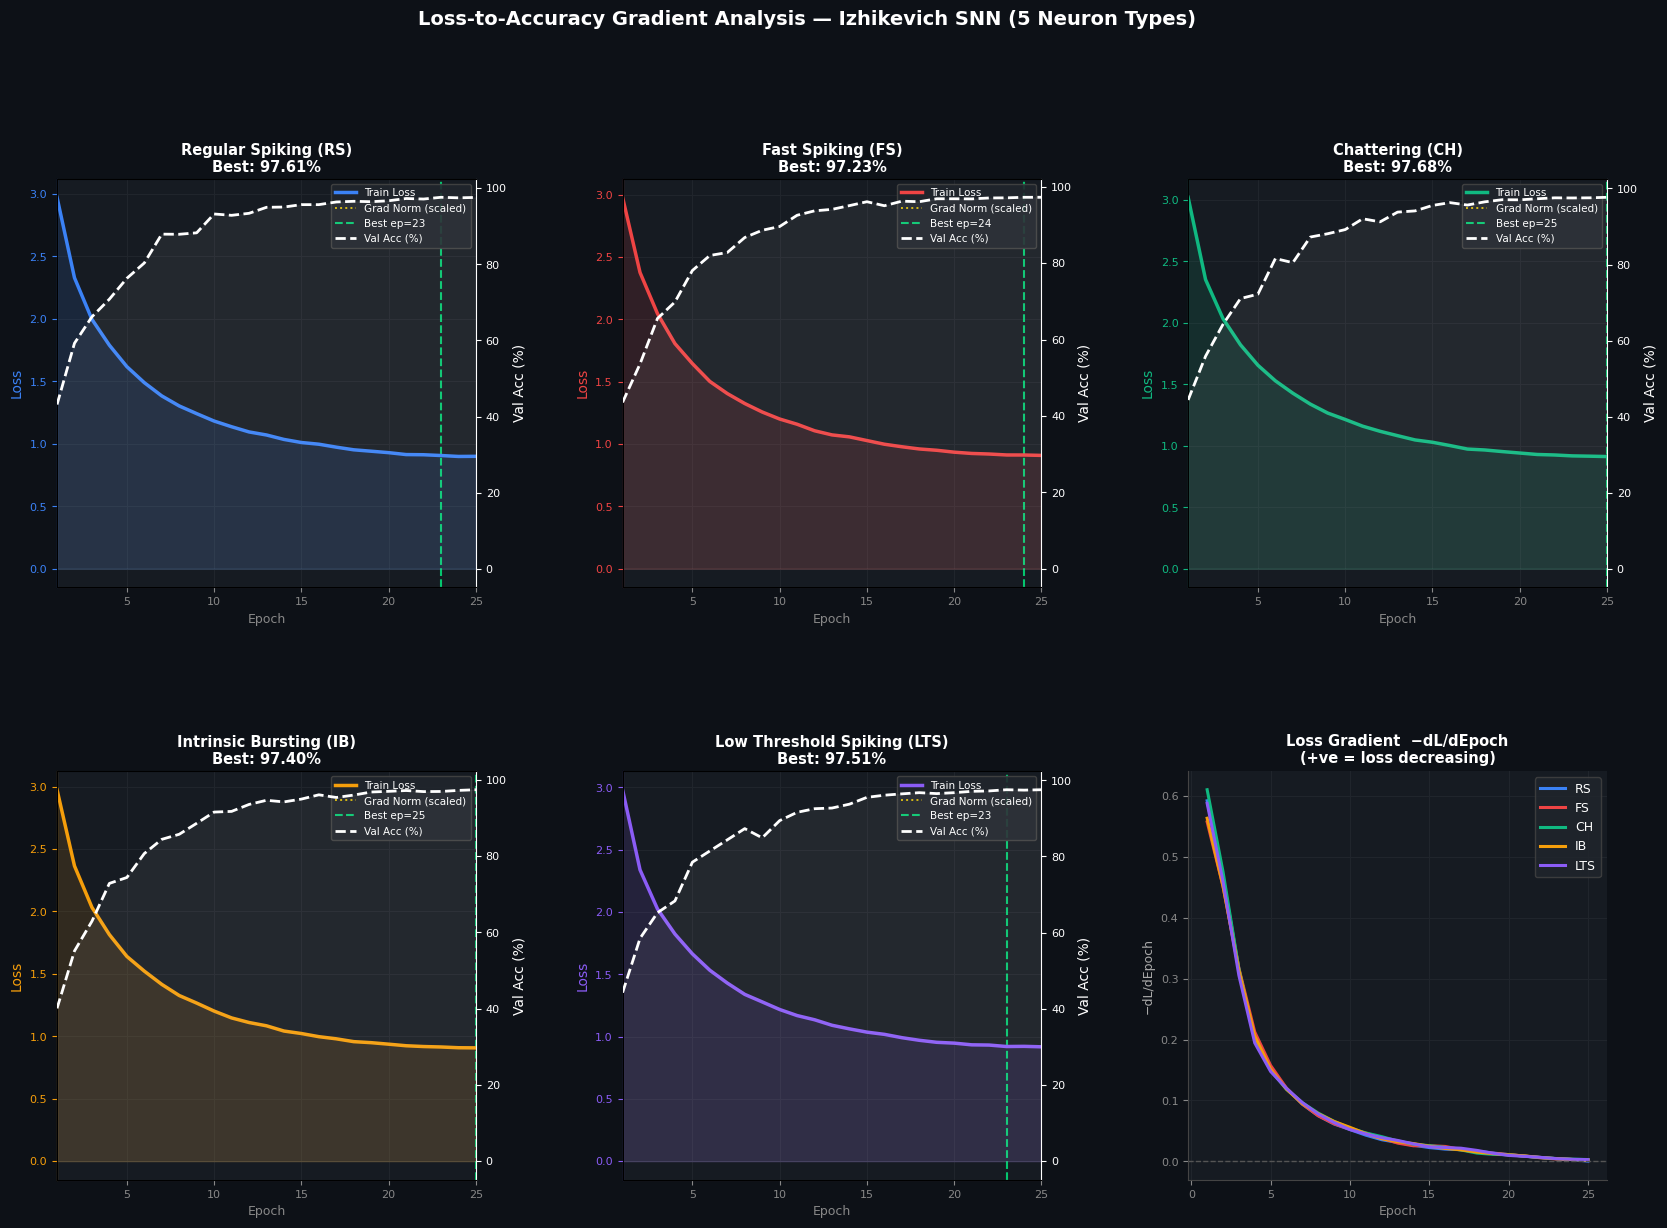

✅  gradient_analysis.png saved


In [35]:
def plot_gradient_analysis(histories, configs):
    """
    5 per-model subplots + 1 combined comparison.

    Each subplot shows:
      • Training loss (primary axis, coloured)
      • Validation accuracy (secondary axis, white dashed)
      • Scaled gradient norm (gold dotted)
      • Best-epoch marker (green dashed vertical)
    Combined panel: −dLoss/dEpoch for all models (learning speed).
    """
    names = list(histories.keys())
    n     = len(names)

    fig   = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor("#0d1117")
    gs    = gridspec.GridSpec(2, 3, figure=fig,
                              hspace=0.45, wspace=0.35)

    for idx, name in enumerate(names):
        ax   = fig.add_subplot(gs[idx // 3, idx % 3])
        ax.set_facecolor("#161b22")
        h    = histories[name]
        cfg  = configs[name]
        col  = cfg["color"]
        E    = np.arange(1, len(h["train_loss"]) + 1)

        tr_loss   = np.array(h["train_loss"])
        vl_acc    = np.array(h["val_acc"]) * 100
        gnorms    = np.array(h["grad_norms"])
        best_ep   = int(np.argmax(vl_acc)) + 1

        # Primary axis: training loss
        ax.plot(E, tr_loss, color=col, linewidth=2.5, label="Train Loss", zorder=3)
        ax.fill_between(E, tr_loss, alpha=0.12, color=col, zorder=2)

        # Scaled gradient norm overlay
        gn_scaled = (gnorms / (gnorms.max() + 1e-8)) * tr_loss.max()
        ax.plot(E, _smooth(gn_scaled), color="#FFD700", linewidth=1.4,
                linestyle=":", alpha=0.8, label="Grad Norm (scaled)", zorder=3)

        # Best epoch marker
        ax.axvline(best_ep, color="#00FF88", linewidth=1.5,
                   linestyle="--", alpha=0.75, label=f"Best ep={best_ep}")

        ax.set_ylabel("Loss", color=col, fontsize=10)
        ax.tick_params(axis="y", colors=col, labelsize=8)
        ax.tick_params(axis="x", colors="#888", labelsize=8)

        # Secondary axis: val accuracy
        ax2 = ax.twinx()
        ax2.plot(E, vl_acc, color="white", linewidth=2.0,
                 linestyle="--", label="Val Acc (%)", zorder=4)
        ax2.fill_between(E, vl_acc, alpha=0.06, color="white", zorder=1)
        ax2.set_ylabel("Val Acc (%)", color="white", fontsize=10)
        ax2.tick_params(axis="y", colors="white", labelsize=8)

        ax.set_title(
            f"{cfg['display']}\nBest: {h['best_val_acc']*100:.2f}%",
            color="white", fontsize=10.5, fontweight="bold", pad=5
        )
        ax.set_xlabel("Epoch", color="#888", fontsize=9)
        ax.set_xlim(1, max(E))
        ax.grid(color="#21262d", linewidth=0.7)

        for spine in ["top"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color(col)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color("#444")
        ax2.spines["right"].set_color("white")

        # Combined legend
        lines1, lab1 = ax.get_legend_handles_labels()
        lines2, lab2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, lab1 + lab2,
                  loc="upper right", fontsize=7.5,
                  facecolor="#21262d", edgecolor="#444",
                  labelcolor="white", framealpha=0.9)

    # Combined panel: −dLoss/dEpoch
    ax_comb = fig.add_subplot(gs[1, 2])
    ax_comb.set_facecolor("#161b22")

    for name in names:
        h   = histories[name]
        col = configs[name]["color"]
        E   = np.arange(1, len(h["train_loss"]) + 1)
        dl  = -np.gradient(np.array(h["train_loss"]), E)
        ax_comb.plot(E, _smooth(dl, w=3), color=col, linewidth=2.2,
                     label=configs[name]["params"].name)

    ax_comb.axhline(0, color="#555", linewidth=1, linestyle="--")
    ax_comb.set_title("Loss Gradient  −dL/dEpoch\n(+ve = loss decreasing)",
                      color="white", fontsize=10.5, fontweight="bold")
    ax_comb.set_xlabel("Epoch", color="#888", fontsize=9)
    ax_comb.set_ylabel("−dL/dEpoch", color="#aaa", fontsize=9)
    ax_comb.tick_params(colors="#888", labelsize=8)
    ax_comb.grid(color="#21262d", linewidth=0.7)
    ax_comb.legend(fontsize=9, facecolor="#21262d",
                   edgecolor="#444", labelcolor="white")
    for spine in ["top", "right"]:
        ax_comb.spines[spine].set_visible(False)
    for spine in ["bottom", "left"]:
        ax_comb.spines[spine].set_color("#444")

    fig.suptitle(
        "Loss-to-Accuracy Gradient Analysis — Izhikevich SNN (5 Neuron Types)",
        color="white", fontsize=14, fontweight="bold", y=1.01,
    )

    plt.savefig("gradient_analysis.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✅  gradient_analysis.png saved")


plot_gradient_analysis(all_histories, NEURON_CONFIGS)

In [ ]:
criterion_test = nn.CrossEntropyLoss()
test_results   = {}

print(f"\n{'═'*62}")
print("  TEST SET EVALUATION")
print(f"{'═'*62}")

for name, model in all_models.items():
    t_loss, t_acc = evaluate_loader(model, test_loader, criterion_test)
    test_results[name] = dict(loss=t_loss, accuracy=t_acc)
    print(f"  {NEURON_CONFIGS[name]['display']:<35} "
          f"Acc={t_acc*100:6.2f}%  Loss={t_loss:.4f}")

best_name = max(test_results, key=lambda n: test_results[n]["accuracy"])
print(f"\n  🏆  Best: {NEURON_CONFIGS[best_name]['display']}")
print(f"       Test Accuracy : {test_results[best_name]['accuracy']*100:.2f}%")



══════════════════════════════════════════════════════════════
  TEST SET EVALUATION
══════════════════════════════════════════════════════════════
  Regular Spiking (RS)                Acc= 97.72%  Loss=0.1766
  Fast Spiking (FS)                   Acc= 97.55%  Loss=0.1821
  Chattering (CH)                     Acc= 97.51%  Loss=0.1819
  Intrinsic Bursting (IB)             Acc= 97.48%  Loss=0.1843
  Low Threshold Spiking (LTS)         Acc= 97.34%  Loss=0.1862

  🏆  Best: Regular Spiking (RS)
       Test Accuracy : 97.72%


Final Bar chart

In [37]:
sorted_res = sorted(test_results.items(), key=lambda x: -x[1]["accuracy"])

fig_final = go.Figure(data=[
    go.Bar(
        x=[NEURON_CONFIGS[n]["display"] for n, _ in sorted_res],
        y=[r["accuracy"] * 100 for _, r in sorted_res],
        marker_color=[NEURON_CONFIGS[n]["color"] for n, _ in sorted_res],
        marker_line_color="white",
        marker_line_width=2,
        text=[f"{r['accuracy']*100:.2f}%" for _, r in sorted_res],
        textposition="outside",
        textfont=dict(color="white", size=13),
    )
])

fig_final.update_layout(
    title=dict(
        text="<b>Final Test Accuracy — Izhikevich SNN Neuron Type Comparison</b>",
        font=dict(size=16, color="white"), x=0.5,
    ),
    xaxis_title="Neuron Type",
    yaxis_title="Test Accuracy (%)",
    yaxis=dict(
        gridcolor="#21262d",
        range=[0, max(r["accuracy"] for r in test_results.values()) * 125],
    ),
    xaxis=dict(gridcolor="#21262d"),
    height=520, width=900,
    paper_bgcolor="#0d1117",
    plot_bgcolor="#161b22",
    font=dict(color="white", size=12),
    showlegend=False,
)

fig_final.write_html("final_comparison.html")
fig_final.show()
print("✅  final_comparison.html saved")

✅  final_comparison.html saved


save histories as Json

In [38]:
_ser = {
    k: {kk: (
            [float(x) for x in vv] if isinstance(vv, list) else float(vv)
        )
        for kk, vv in h.items()}
    for k, h in all_histories.items()
}
with open("training_histories.json", "w") as f:
    json.dump(_ser, f, indent=2)
print("✅  training_histories.json saved")

✅  training_histories.json saved


Printed Summary

In [39]:
print(f"\n{'═'*62}")
print("  FINAL SUMMARY")
print(f"{'═'*62}")
print(f"  {'Neuron Type':<35} {'Val Acc':>8}  {'Test Acc':>9}")
print(f"  {'─'*58}")
for name in [n for n, _ in sorted_res]:
    v = all_histories[name]["best_val_acc"] * 100
    t = test_results[name]["accuracy"] * 100
    print(f"  {NEURON_CONFIGS[name]['display']:<35} {v:8.2f}%  {t:8.2f}%")
print(f"\n  Best neuron type  : {NEURON_CONFIGS[best_name]['display']}")
print(f"  Izhikevich params : {NEURON_CONFIGS[best_name]['params']}")

print(f"\n{'─'*55}")
print("  Output files")
print(f"{'─'*55}")
for fn, desc in [
    ("spike_patterns.png",          "Neuron voltage traces"),
    ("snn_training_dashboard.html", "Interactive training dashboard"),
    ("gradient_analysis.png",       "Loss-to-accuracy gradient analysis"),
    ("final_comparison.html",       "Final accuracy bar chart"),
    ("training_histories.json",     "Raw training data (JSON)"),
]:
    print(f"    {fn:<38} {desc}")
print(f"{'─'*55}")


══════════════════════════════════════════════════════════════
  FINAL SUMMARY
══════════════════════════════════════════════════════════════
  Neuron Type                          Val Acc   Test Acc
  ──────────────────────────────────────────────────────────
  Regular Spiking (RS)                   97.61%     97.72%
  Fast Spiking (FS)                      97.23%     97.55%
  Chattering (CH)                        97.68%     97.51%
  Intrinsic Bursting (IB)                97.40%     97.48%
  Low Threshold Spiking (LTS)            97.51%     97.34%

  Best neuron type  : Regular Spiking (RS)
  Izhikevich params : IzhikevichParameters(a=0.02, b=0.2, c=-65.0, d=8.0)

───────────────────────────────────────────────────────
  Output files
───────────────────────────────────────────────────────
    spike_patterns.png                     Neuron voltage traces
    snn_training_dashboard.html            Interactive training dashboard
    gradient_analysis.png                  Loss-to-accurac

In [ ]:
# ── Save full model object for deployment ─────────────────────────────────
import torch
torch.save(all_models["Regular_Spiking"], "regular_spiking_model.pt")
print("✅  regular_spiking_model.pt saved (full model object)")
